In [ ]:
#I built a Walmart sales prediction model using Random Forest. 
#I performed data cleaning, handled missing values, encoded categorical features, and analyzed correlations. 
#After splitting the data, I trained the model and achieved strong performance using R²((Coefficient of Determination)) and MAE((Mean Absolute Error) metrics. 
#I also analyzed feature importance to understand key drivers like Item MRP and Outlet Type impacting sales.”

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [29]:
!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [105]:
df = pd.read_excel("walmart_sales_dataset.xlsx")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,ID_0,10.62,Low Fat,0.1131,Meat,212.87,OUT_0,1988,High,Tier 3,Supermarket,3593.46
1,ID_1,19.26,Regular,0.1682,Fruits,179.17,OUT_1,2008,Small,Tier 3,Grocery Store,2096.79
2,ID_2,15.98,Low Fat,0.0338,Household,297.97,OUT_2,1997,Medium,Tier 1,Supermarket,4836.66
3,ID_3,13.98,Regular,0.0347,Soft Drinks,63.66,OUT_3,1993,Small,Tier 2,Grocery Store,701.62
4,ID_4,7.34,Regular,0.1158,Meat,172.76,OUT_4,1987,Small,Tier 1,Supermarket,2278.00


In [106]:
print(df.shape)

(5000, 12)


In [107]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5000 non-null   str    
 1   Item_Weight                5000 non-null   float64
 2   Item_Fat_Content           5000 non-null   str    
 3   Item_Visibility            5000 non-null   float64
 4   Item_Type                  5000 non-null   str    
 5   Item_MRP                   5000 non-null   float64
 6   Outlet_Identifier          5000 non-null   str    
 7   Outlet_Establishment_Year  5000 non-null   int64  
 8   Outlet_Size                5000 non-null   str    
 9   Outlet_Location_Type       5000 non-null   str    
 10  Outlet_Type                5000 non-null   str    
 11  Item_Outlet_Sales          5000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 468.9 KB
None


In [108]:
print(df.isnull().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [109]:
df.describe(include ='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,5000,5000,ID_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,5000.0,NaN,NaN,NaN,12.452496,4.344518,5.0,8.6575,12.5,16.22,20.0
Item_Fat_Content,5000,2,Low Fat,2508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,5000.0,NaN,NaN,NaN,0.104426,0.054577,0.01,0.057875,0.1038,0.1518,0.1999
Item_Type,5000,5,Soft Drinks,1042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,5000.0,NaN,NaN,NaN,177.637972,71.994384,50.06,116.925,179.05,238.565,299.98
Outlet_Identifier,5000,10,OUT_0,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,5000.0,NaN,NaN,NaN,1999.4876,8.626791,1985.0,1992.0,1999.0,2007.0,2014.0
Outlet_Size,5000,3,High,1689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,5000,3,Tier 2,1721,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
#Extracting unique value 
for i in df.columns: 
    print(i,':distinct_value') 
    print(df[i].nunique(),"No. of unique values") 
    print(df[i].unique()) 
    print("-"*30) 
    print("")

Item_Identifier :distinct_value
5000 No. of unique values
<StringArray>
[   'ID_0',    'ID_1',    'ID_2',    'ID_3',    'ID_4',    'ID_5',    'ID_6',
    'ID_7',    'ID_8',    'ID_9',
 ...
 'ID_4990', 'ID_4991', 'ID_4992', 'ID_4993', 'ID_4994', 'ID_4995', 'ID_4996',
 'ID_4997', 'ID_4998', 'ID_4999']
Length: 5000, dtype: str
------------------------------

Item_Weight :distinct_value
1440 No. of unique values
[10.62 19.26 15.98 ... 11.67 13.53 13.19]
------------------------------

Item_Fat_Content :distinct_value
2 No. of unique values
<StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str
------------------------------

Item_Visibility :distinct_value
1768 No. of unique values
[0.1131 0.1682 0.0338 ... 0.0112 0.0514 0.0811]
------------------------------

Item_Type :distinct_value
5 No. of unique values
<StringArray>
['Meat', 'Fruits', 'Household', 'Soft Drinks', 'Dairy']
Length: 5, dtype: str
------------------------------

Item_MRP :distinct_value
4555 No. of unique values
[212.

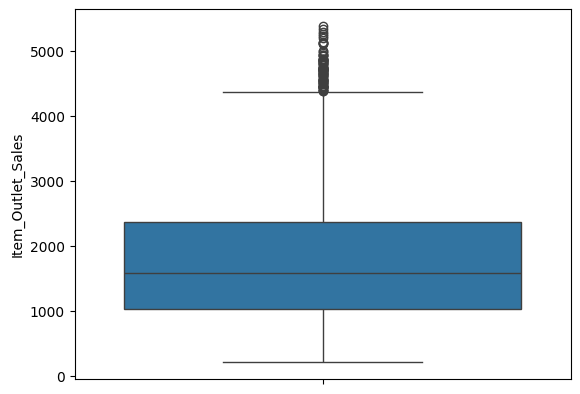

In [111]:
#Prediction for Item_Outlet_Sales using boxplot 
sns.boxplot(df.Item_Outlet_Sales) 
plt.show()

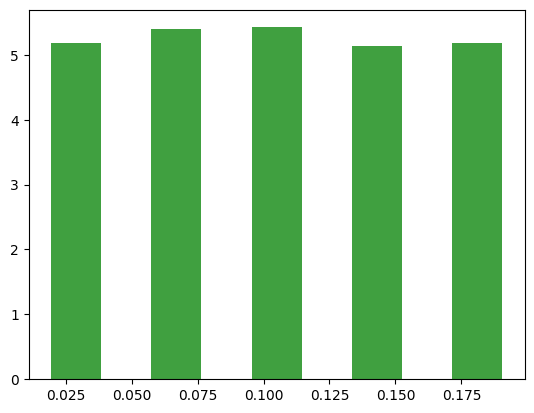

In [112]:
#Prediction for Item_Visibility using hist 
plt.hist(df.Item_Visibility,rwidth=.5,bins=5,density=True,facecolor='g', alpha=0.75) 
plt.show() 

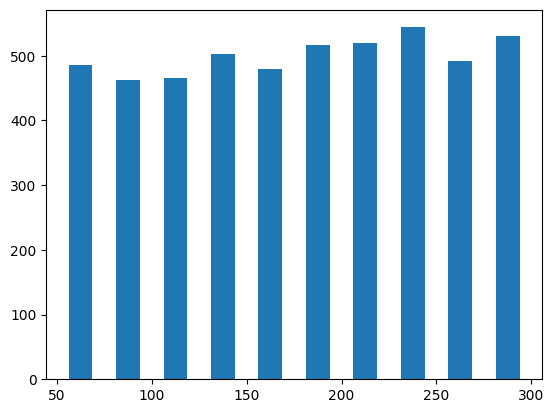

In [113]:
# Prediction for Item_MRP using hist 
plt.hist(df.Item_MRP,rwidth=.5, bins = 10) 
plt.show() 

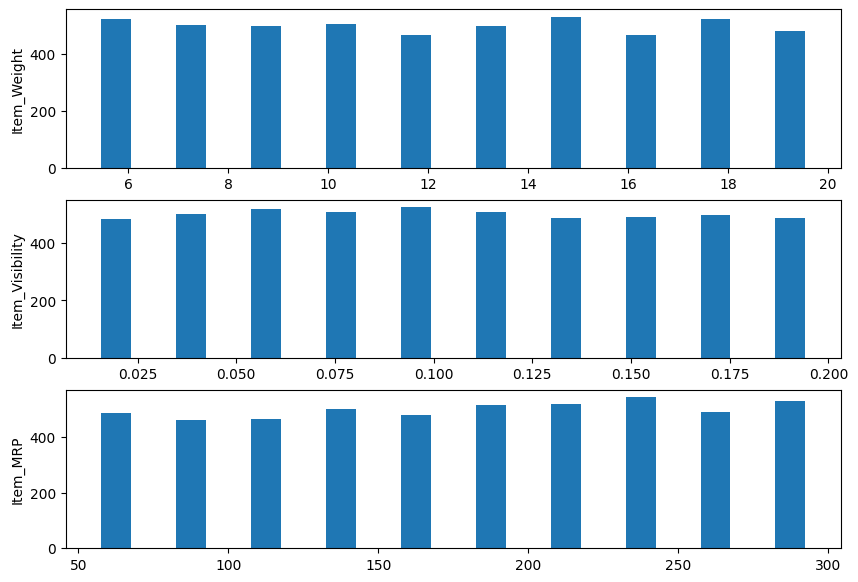

In [114]:
# Prediction for Item_Weight, Item_Visibility, Item_MRP 
plt.figure(figsize = (10,7)) 
for i, col in enumerate (['Item_Weight','Item_Visibility','Item_MRP']): 
    plt.subplot(3,1,i+1) 
    plt.hist(df[col], rwidth = .4) 
    plt.xlabel('') 
    plt.ylabel(col) 

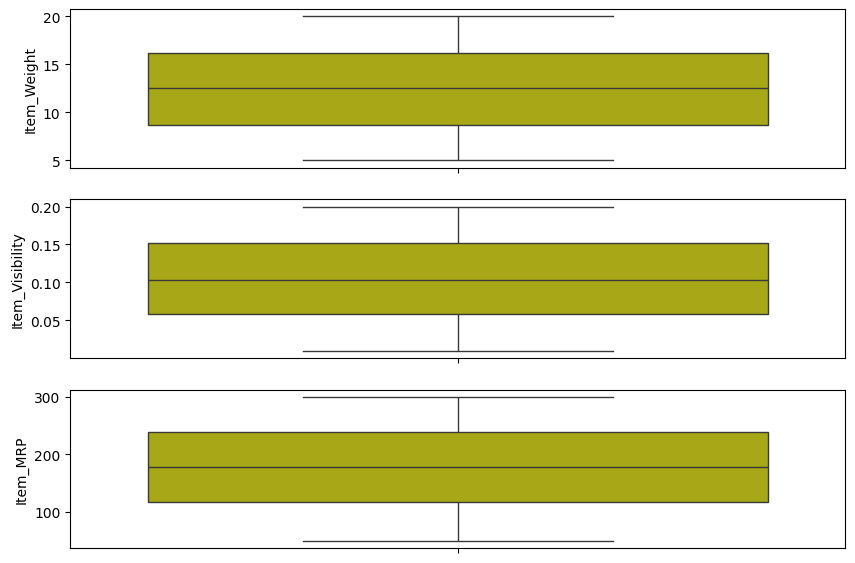

In [115]:
#Prediction for Item_Weight, Item_Visibility, Item_MRP using boxplot
plt.figure(figsize = (10,7)) 
for i, col in enumerate (['Item_Weight','Item_Visibility','Item_MRP']): 
    plt.subplot(3,1,i+1) 
    sns.boxplot(df[col], color ='y') 
    plt.xlabel('') 
    plt.ylabel(col)

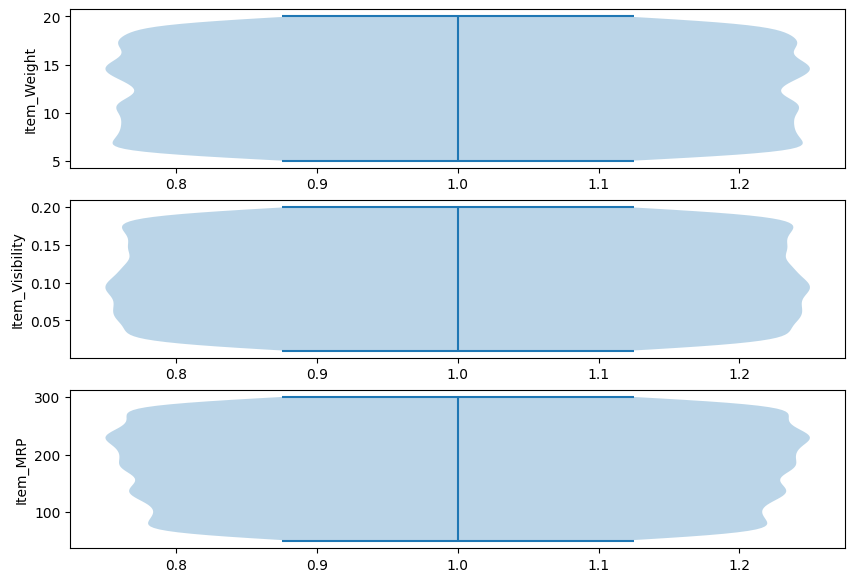

In [116]:
# Prediction for Item_Weight, Item_Visibility, Item_MRP using violinplot
plt.figure(figsize = (10,7)) 
for i, col in enumerate (['Item_Weight','Item_Visibility','Item_MRP']): 
    plt.subplot(3,1,i+1) 
    plt.violinplot(df[col]) 
    plt.xlabel('') 
    plt.ylabel(col) 

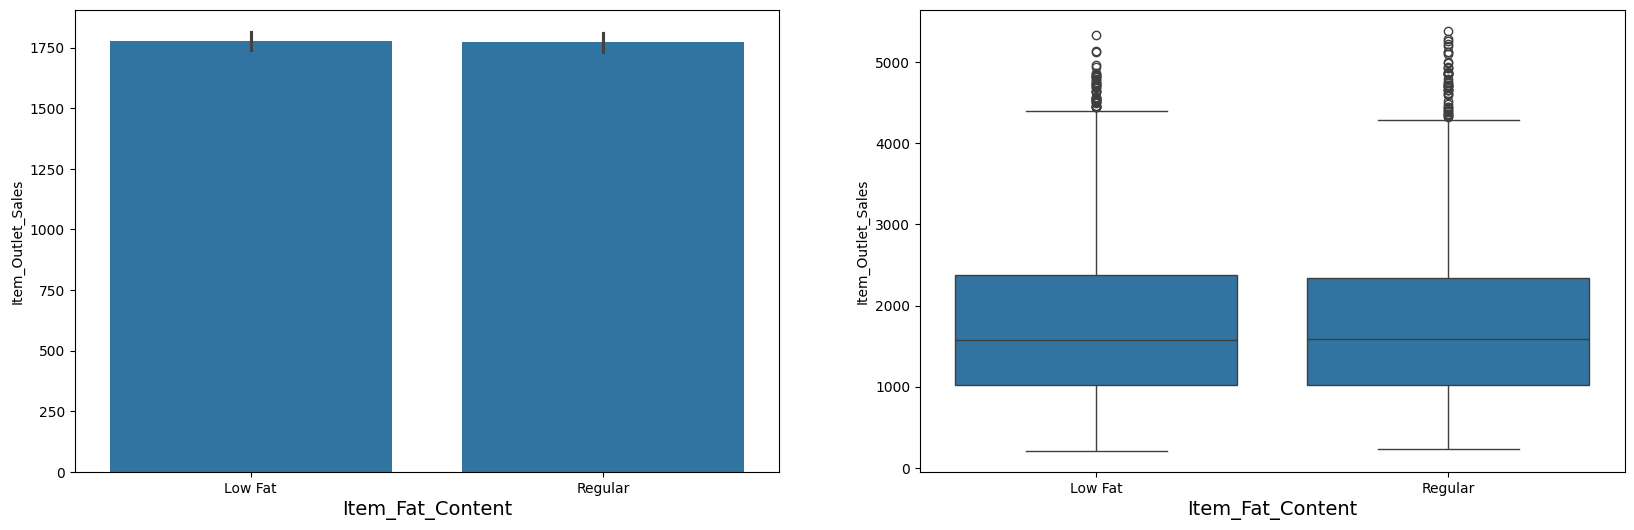

In [117]:
#Prediction for Item_Outlet_Sales, Item_Fat_Content
plt.figure(figsize=(20,6)) 
plt.subplot(1,2,1) 
sns.barplot(data=df, y='Item_Outlet_Sales', x='Item_Fat_Content') 
plt.xlabel('Item_Fat_Content', fontsize=14) 
plt.subplot(1,2,2) 
sns.boxplot(data=df, y='Item_Outlet_Sales', x='Item_Fat_Content') 
plt.xlabel('Item_Fat_Content', fontsize=14) 
plt.show()

In [118]:
# Detecting missing values using isna
round(100*(df.isna().sum())/len(df),2)

Item_Identifier              0.0
Item_Weight                  0.0
Item_Fat_Content             0.0
Item_Visibility              0.0
Item_Type                    0.0
Item_MRP                     0.0
Outlet_Identifier            0.0
Outlet_Establishment_Year    0.0
Outlet_Size                  0.0
Outlet_Location_Type         0.0
Outlet_Type                  0.0
Item_Outlet_Sales            0.0
dtype: float64

In [119]:
# changing the data to Zero 
df[df==0].sum() 

Item_Identifier                0
Item_Weight                  0.0
Item_Fat_Content               0
Item_Visibility              0.0
Item_Type                      0
Item_MRP                     0.0
Outlet_Identifier              0
Outlet_Establishment_Year    0.0
Outlet_Size                    0
Outlet_Location_Type           0
Outlet_Type                    0
Item_Outlet_Sales            0.0
dtype: object

In [120]:
# Filling the NaN values using fillna 
df['Item_Weight'].fillna(df["Item_Weight"].mean(), inplace=True) 
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17832\1308249067.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Item_Weight'].fillna(df["Item_Weight"].mean(), inplace=True)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,ID_0,10.62,Low Fat,0.1131,Meat,212.87,OUT_0,1988,High,Tier 3,Supermarket,3593.46
1,ID_1,19.26,Regular,0.1682,Fruits,179.17,OUT_1,2008,Small,Tier 3,Grocery Store,2096.79
2,ID_2,15.98,Low Fat,0.0338,Household,297.97,OUT_2,1997,Medium,Tier 1,Supermarket,4836.66
3,ID_3,13.98,Regular,0.0347,Soft Drinks,63.66,OUT_3,1993,Small,Tier 2,Grocery Store,701.62
4,ID_4,7.34,Regular,0.1158,Meat,172.76,OUT_4,1987,Small,Tier 1,Supermarket,2278.00


In [121]:
#Correlating of all columns in the dataframe
df.corr(numeric_only=True)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.016212,-0.008245,-0.005552,-0.011417
Item_Visibility,-0.016212,1.000000,-0.002409,0.016028,-0.022393
Item_MRP,-0.008245,-0.002409,1.000000,-0.030901,0.716668
Outlet_Establishment_Year,-0.005552,0.016028,-0.030901,1.000000,-0.021847
Item_Outlet_Sales,-0.011417,-0.022393,0.716668,-0.021847,1.000000


In [122]:
#Handle Missing Values (if any)
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [123]:
#Drop Unnecessary Columns
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True, errors='ignore')

In [124]:
# Detecting missing values dataset using isna 
df.isna().sum()

Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [125]:
# Filling the NaN values from dataset 
map1 = {"Small":1,"Medium":2,"High":3} 
df["Outlet_Size"] = df["Outlet_Size"].map(map1) 
df["Item_Weight"] = df["Item_Weight"].fillna(df.Item_Weight.mean()) 
df["Outlet_Size"] = df["Outlet_Size"].fillna(df["Outlet_Size"].median()) 
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,10.62,Low Fat,0.1131,Meat,212.87,1988,3,Tier 3,Supermarket,3593.46
1,19.26,Regular,0.1682,Fruits,179.17,2008,1,Tier 3,Grocery Store,2096.79
2,15.98,Low Fat,0.0338,Household,297.97,1997,2,Tier 1,Supermarket,4836.66
3,13.98,Regular,0.0347,Soft Drinks,63.66,1993,1,Tier 2,Grocery Store,701.62
4,7.34,Regular,0.1158,Meat,172.76,1987,1,Tier 1,Supermarket,2278.00


In [126]:
#Encode Categorical Variables
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [127]:
corr = df.corr(numeric_only=True)
print(corr['Item_Outlet_Sales'].sort_values(ascending=False))

Item_Outlet_Sales            1.000000
Item_MRP                     0.716668
Outlet_Type                  0.366346
Outlet_Location_Type         0.014370
Item_Type                    0.002468
Item_Fat_Content            -0.004017
Item_Weight                 -0.011417
Outlet_Establishment_Year   -0.021847
Item_Visibility             -0.022393
Outlet_Size                 -0.040286
Name: Item_Outlet_Sales, dtype: float64


In [128]:
#Split Data
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
#Train Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [130]:
#Predictions
y_pred = model.predict(X_test)

In [131]:
#Model Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.6421382274552576
MAE: 472.7299667
